# Survey quota sampling with `datacarve`

Online survey panels rarely look like the population: they skew young, urban and
toward whichever gender signed up more. **Quota sampling** fixes this by selecting
a subset of respondents that matches census demographics.

Matching quotas on one attribute is trivial. Matching **age structure, gender and
region simultaneously** is not: every respondent you pick counts toward three
quotas at once. [`datacarve`](https://github.com/bbonik/datacarve) solves the
joint problem exactly with mixed integer linear programming.

This notebook is fully self-contained (synthetic data, fixed seed).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datacarve import undersample_dataset

plt.style.use("ggplot")
rng = np.random.default_rng(7)

## 1. A skewed respondent panel

10,000 panel members. Age skews young (folded gaussian around 25), women are
under-represented, and the urban region dominates.


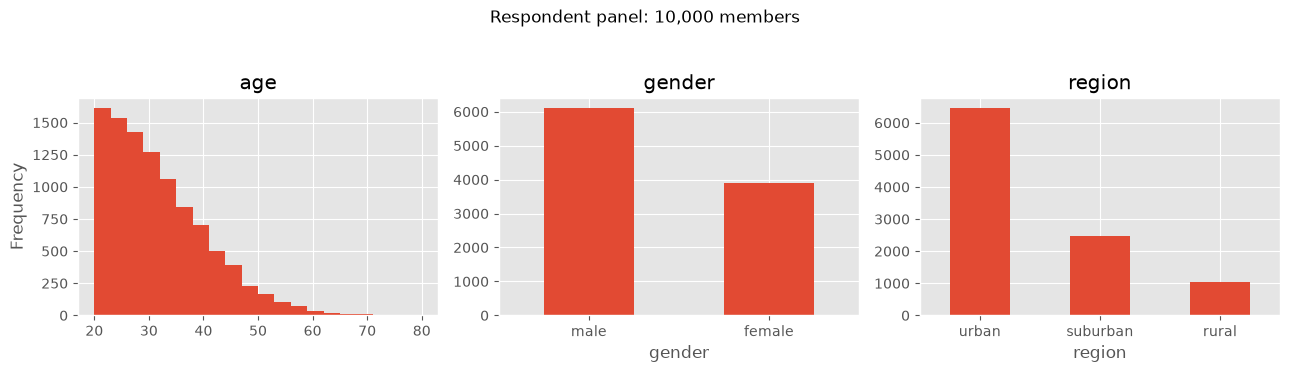

In [2]:
N = 10_000

age = np.clip(20 + np.abs(rng.normal(5, 14, N)), 18, 80)          # skews young
gender = rng.choice([0.0, 1.0], N, p=[0.62, 0.38])                # 0=M, 1=F
region = rng.choice([0.0, 1.0, 2.0], N, p=[0.65, 0.25, 0.10])     # urban/suburban/rural

panel = pd.DataFrame({"age": age, "gender": gender, "region": region})
REGION_NAMES = {0.0: "urban", 1.0: "suburban", 2.0: "rural"}
GENDER_NAMES = {0.0: "male", 1.0: "female"}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
panel["age"].plot.hist(bins=20, ax=axes[0], title="age")
panel["gender"].map(GENDER_NAMES).value_counts().plot.bar(ax=axes[1], title="gender", rot=0)
panel["region"].map(REGION_NAMES).value_counts().plot.bar(ax=axes[2], title="region", rot=0)
plt.suptitle(f"Respondent panel: {N:,} members", y=1.05)
plt.tight_layout()
plt.show()

## 2. Census-style quota targets

Say the census tells us the population looks like this:

| Attribute | Target |
|---|---|
| Age 18–80, in 10 bins | more mass in middle age, tapering at both ends |
| Gender | 50 / 50 |
| Region | urban 45%, suburban 35%, rural 20% |

Each attribute gets its own target spec. The age target is a custom histogram
(one weight per bin); gender and region are categorical.


In [3]:
age_census = [6, 9, 11, 12, 12, 12, 11, 10, 9, 8]   # weights per age bin (18-80)

mask = undersample_dataset(
    data=panel.to_numpy(),
    data_to_keep=1_500,
    target_distribution=[
        age_census,        # age: census age structure
        "uniform",         # gender: 50/50
        [45, 35, 20],      # region: census shares
    ],
    categorical_dims=[1, 2],
    bins=10,
    solver="CBC",
    max_solver_time_sec=60,
    verbose=False,
    scatterplot_matrix=False,
)

sample = panel[mask]
print(f"quota sample: {mask.sum()} respondents")

quota sample: 1500 respondents


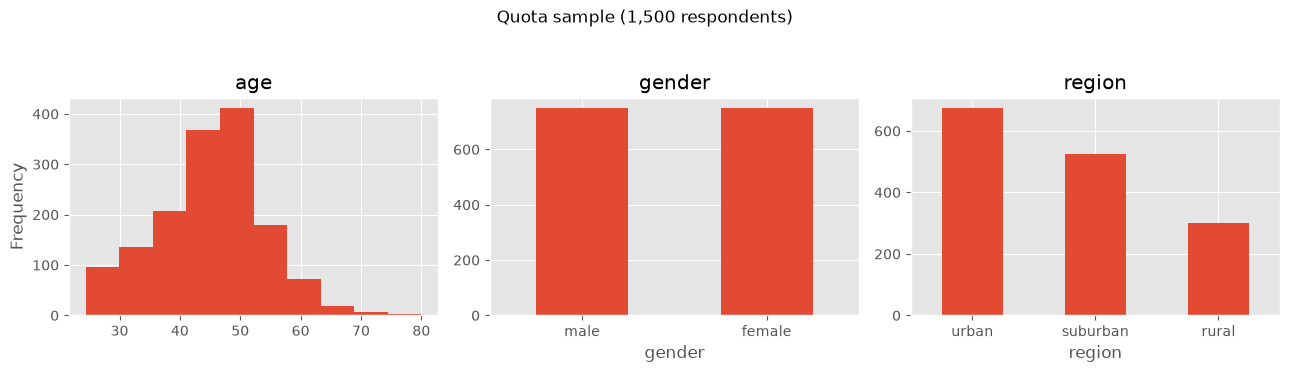

gender: {'male': 750, 'female': 750}
region: {'urban': 675, 'suburban': 525, 'rural': 300}
region targets: {'urban': 675, 'suburban': 525, 'rural': 300}


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
sample["age"].plot.hist(bins=10, ax=axes[0], title="age")
sample["gender"].map(GENDER_NAMES).value_counts().plot.bar(ax=axes[1], title="gender", rot=0)
sample["region"].map(REGION_NAMES).value_counts().plot.bar(ax=axes[2], title="region", rot=0)
plt.suptitle("Quota sample (1,500 respondents)", y=1.05)
plt.tight_layout()
plt.show()

print("gender:", sample["gender"].map(GENDER_NAMES).value_counts().to_dict())
print("region:", sample["region"].map(REGION_NAMES).value_counts().to_dict())

expected_region = {"urban": 675, "suburban": 525, "rural": 300}
print("region targets:", expected_region)

The sample hits the quotas: 750/750 gender split, region at its exact 45/35/20
shares, and the age histogram reshaped from the panel's young skew to the census
structure — all in one optimization over 10,000 binary decisions.

## 3. Sanity check: how far is each marginal from its target?


In [5]:
def deviation_report(sample):
    rows = []

    # age: compare achieved vs target histogram
    achieved, _ = np.histogram(sample["age"], bins=10, range=(sample["age"].min(), sample["age"].max()))
    target = np.array(age_census, float)
    target = target / target.sum() * len(sample)
    rows.append(("age (max bin deviation)", int(np.abs(achieved - target).max())))

    # gender
    counts = sample["gender"].value_counts()
    rows.append(("gender (max deviation)", int((counts - len(sample) / 2).abs().max())))

    # region
    target_region = np.array([45, 35, 20], float) / 100 * len(sample)
    counts = sample["region"].value_counts().sort_index().to_numpy()
    rows.append(("region (max deviation)", int(np.abs(counts - target_region).max())))

    return pd.DataFrame(rows, columns=["marginal", "deviation (respondents)"])

deviation_report(sample)

,marginal,deviation (respondents)
0,age (max bin deviation),232
1,gender (max deviation),0
2,region (max deviation),0


## Wrap-up

- One `undersample_dataset` call replaced the usual iterative quota juggling:
  age structure, gender and region matched **jointly and exactly** (deviations
  of a few respondents at most, guaranteed minimal by the MILP).
- The same pattern works for panel calibration, A/B group assignment, and
  cohort matching in observational studies.

**Install:** `pip install datacarve` &nbsp;|&nbsp; **Repo:**
<https://github.com/bbonik/datacarve>
